In [103]:
import tensorflow as tf
import numpy as np

In [104]:
tf.config.list_physical_devices('GPU')

[]

In [105]:
def categorize_labels(label: float) -> float:
    if label < 0.1:
        return 0.0
    
    return 1.0

In [106]:
data = np.loadtxt('stock_context_curated.csv', delimiter=',')
data = data.T
np.random.shuffle(data)
data = data.T

In [107]:
raw_T = data[0:252,:]
raw_SP = data[252:504,:]
raw_Y = np.array(data[-1:,:])
X = np.array(list(zip(raw_T, raw_SP))) # Zip to make s&p and ticker days align
Y = (tf.keras.utils.to_categorical(raw_Y, 2)).T

assert(raw_T[0,0] == X[0,0,0] and raw_SP[0,0] == X[0,1,0])

In [108]:
Y.shape = (Y.shape[0], Y.shape[1])
print(X.shape)
print(Y.shape)

(252, 2, 74343)
(2, 74343)


In [109]:
print("Worse Than s&p:", np.count_nonzero(Y[0]))
print("Better Than s&p:", np.count_nonzero(Y[1]))

Worse Than s&p: 31591
Better Than s&p: 42752


In [110]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(2, 252)),
    tf.keras.layers.Dense(50, activation='tanh', kernel_initializer='glorot_uniform'),
    tf.keras.layers.Dense(50, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(50, activation='tanh', kernel_initializer='glorot_uniform'),
    tf.keras.layers.Dense(50, activation='relu', kernel_initializer='he_normal'),
    #tf.keras.layers.Reshape((252,1)),
    #tf.keras.layers.LSTM(252, activation='tanh', recurrent_activation='relu', kernel_initializer='he_normal'),
    #tf.keras.layers.Reshape((512, 1)),
    #tf.keras.layers.Conv1D(filters=30, kernel_size=7, activation='relu', padding='same'),
    #tf.keras.layers.Reshape((14,1)),
    #tf.keras.layers.MaxPooling1D(pool_size=2),
    #tf.keras.layers.Flatten(), 
    tf.keras.layers.Dense(2, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 504)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 50)             │        25,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 2)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,002 (128.91 KB)

 Trainable params: 33,002 (128.91 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
train_size = int(data.shape[1] * 0.8)

X_train = X[:,:,:train_size].T
Y_train = Y[:,:train_size].T

X_val = X[:,:,train_size:].T
Y_val = Y[:,train_size:].T

mean = X_train.mean(axis=0)
std  = X_train.std(axis=0) + 1e-8
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std

print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)

(59474, 2, 252)
(59474, 2)
(14869, 2, 252)
(14869, 2)


In [112]:
model.fit(X_train, Y_train,
                  validation_data=(X_val,Y_val),
                  batch_size=64, 
                  epochs=300,
                  verbose=1,
                  shuffle=True)

Epoch 1/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5659 - loss: 0.6873 - val_accuracy: 0.5637 - val_loss: 0.6855
Epoch 2/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5826 - loss: 0.6745 - val_accuracy: 0.5622 - val_loss: 0.6910
Epoch 3/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6064 - loss: 0.6597 - val_accuracy: 0.5542 - val_loss: 0.6955
Epoch 4/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6396 - loss: 0.6352 - val_accuracy: 0.5491 - val_loss: 0.7148
Epoch 5/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 954us/step - accuracy: 0.6728 - loss: 0.6051 - val_accuracy: 0.5354 - val_loss: 0.7373
Epoch 6/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 962us/step - accuracy: 0.7020 - loss: 0.5723 - val_accuracy: 0.5417 - val_loss: 0.7581
Epoch 7/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 935us/step - accuracy: 0.7272 - loss: 0.5407 - val_accuracy: 0.5374 - val_loss: 0.7959
Epoch 8/300
930/930 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - accuracy: 0.7523 - loss: 0.5071 - 

KeyboardInterrupt: 

In [113]:
import matplotlib.pyplot as plt

def plot_acc_and_loss(history, title):
    plt.title("Model and Validation MAE for " + title)
    xs = list(range(1, len(history.history['accuracy']) + 1))
    plt.plot(xs, history.history['accuracy'], label="Model Accuracy", color="Red")
    plt.plot(xs, history.history['val_accuracy'], label="Validation Accuracy", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.title("Model and Validation Loss for " + title)
    xs = list(range(1, len(history.history['val_loss']) + 1))
    plt.plot(xs, history.history['loss'], label="Model loss", color="Red")
    plt.plot(xs, history.history['val_loss'], label="Validation loss", color="Blue")
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.legend()
    plt.show()

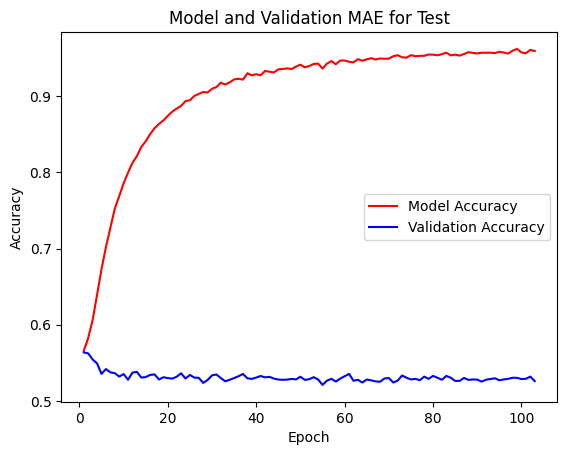

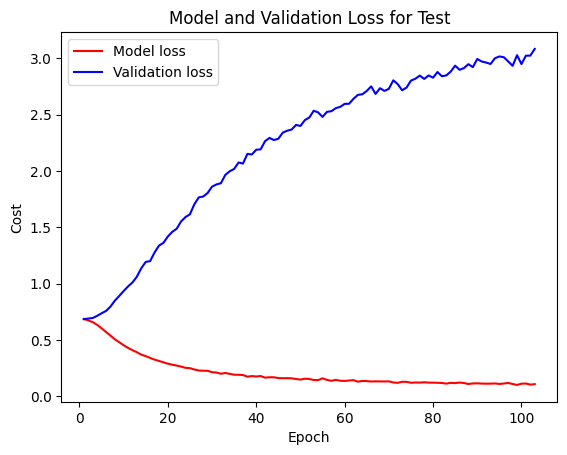

In [114]:
plot_acc_and_loss(model.history, "Test")

In [102]:
print("Prediction:", model(X_val[5:10]))
print("Label:", Y_val[5:10])

Prediction: tf.Tensor(
[[9.9999678e-01 3.1685800e-06]
 [9.9621981e-01 3.7801582e-03]
 [4.8464304e-04 9.9951541e-01]
 [2.5733770e-04 9.9974269e-01]
 [6.6386998e-01 3.3613002e-01]], shape=(5, 2), dtype=float32)
Label: [[1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]
